In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("C:\\Users\\soham\\Downloads\\bank-full.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [12]:
df.info()
df.describe().transpose().drop('count',axis=1)

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,mean,std,min,25%,50%,75%,max
age,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


# **Continous features**

In [13]:
df=pd.read_csv("C:\\Users\\soham\\Downloads\\bank-full.csv")
cols = [
    'age','duration','campaign','pdays','previous',
    'emp.var.rate','cons.price.idx','cons.conf.idx',
    'euribor3m','nr.employed'
]

df[cols].head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0


# **Categorical Features**

In [14]:
df=pd.read_csv("C:\\Users\\soham\\Downloads\\bank-full.csv")
cols = [
    'job','marital',
   'education',
   'default',
   'housing',
    'loan',
   'contact',
   'month',
    'day_of_week'
]

df[cols].head()
df2=pd.get_dummies(data=df[cols],drop_first=True)
df2.head()

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed
0,False,False,True,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
1,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,False
4,False,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [15]:
X=pd.get_dummies(data=df,drop_first=True)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_X=scaler.fit_transform(X)

### Creating and Fitting a KMeans Model

Note of our method choices here:

* fit(X[, y, sample_weight])
    * Compute k-means clustering.

* fit_predict(X[, y, sample_weight])
    * Compute cluster centers and predict cluster index for each sample.

* fit_transform(X[, y, sample_weight])
    * Compute clustering and transform X to cluster-distance space.

* predict(X[, sample_weight])
    * Predict the closest cluster each sample in X belongs to.

In [16]:
from sklearn.cluster import KMeans

MAIN PARAMETERS -

1.n_clusters = Number of clusters you want

2.init = init decides how the initial cluster centers (centroids) are chosen
        before KMeans starts iterating.(KMeans++)

 -Chooses the first centroid randomly

 -Chooses the next centroids far away from existing ones

 -Spreads centroids across the data

 3.max_iter = maximum number of iterations KMeans is allowed to run

 One iteration =  Assign each data point to the nearest centroid,Recompute centroids as the mean of assigned points

This repeats until:  centroids stop moving (converged) ✅
OR max_iter is reached ⛔


In [17]:
model=KMeans(n_clusters=2)
cluster_labels=model.fit_predict(scaled_X)
cluster_labels

array([0, 0, 0, ..., 1, 1, 1], shape=(41188,), dtype=int32)

# Joining with the original data

In [18]:
df['Cluster']=cluster_labels
df=df.set_index('Cluster')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
Cluster,,,,,,,,,,,,,,,,,,,,,
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
0,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
0,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
0,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Choosing K Value

Text(0, 0.5, ' Sum of Squared Distances')

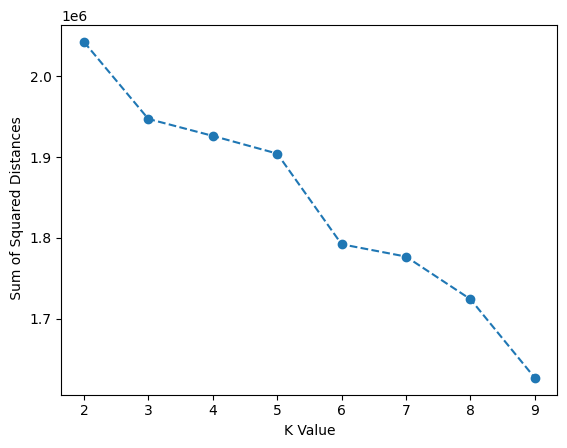

In [19]:
#sum of squared distance
ssd = []
for k in range(2,10):
    model = KMeans(n_clusters=k)
    model.fit(scaled_X)
    #Sum of squared distances of samples to their closest cluster center.
    ssd.append(model.inertia_)

'''
What is inertia_ in KMeans?

inertia_ = total within-cluster sum of squared distances

In simple words 👇
👉 It measures how tight / compact the clusters are  '''

#PLOTTING
plt.plot(range(2,10),ssd,'o--' )
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

In [20]:
from sklearn.metrics import silhouette_score

for k in range(2, 9):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_X)
    score = silhouette_score(scaled_X, labels)

    print(k, round(score,3))


2 0.286
3 0.13
4 0.052
5 0.058
6 0.06
7 0.049
8 0.058
